## Creating the map for overlap

#### Imports

In [1]:
from pathlib import Path
import zipfile
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
import random
from shapely.geometry import LineString, Polygon, Point, MultiPolygon
import numpy as np
import networkx as nx
from itertools import combinations
import osmnx as ox
import tobler
from collections import defaultdict
import pickle


In [2]:
cycle = 6

# Load generations data from pickle file
with open(f"../Results/Built_from_scratch_population/{cycle}/{cycle}_gen_data.pkl", "rb") as f:
    loaded_generations = pickle.load(f)

#### Pre-defined functions (made by us)

In [3]:
## Sum the nodes total weight by all trips to said node

def create_weights(df, od_df):
    weighted_df = df.copy()
    weighted_df["weight"] = ""

    all_nodes = df["cell_id"].tolist()
    
    for unique_node in all_nodes:
        total_weight = 0
        total_weight = od_df.loc[
                (od_df["o"] == unique_node) | (od_df["d"] == unique_node),
                "weight"
            ].sum() 

        weighted_df.loc[weighted_df["cell_id"] == unique_node, 'weight'] = total_weight
 
        # IF we need to save this file for later, uncoment this part - otherwise it will update it 
        # weighted_df.to_csv("Hexagon_weighted_data_new.csv", index=False) 

    return weighted_df

def finding_neighbors(pointes_weighted, grid):
    weighted_grid = grid.copy()

    weighted_grid = weighted_grid.merge(
    pointes_weighted[['cell_id', 'weight']], on='cell_id', how='left')

    mytree = weighted_grid.sindex
    weighted_grid["vicinity"] = weighted_grid.apply(
        lambda x: weighted_grid.iloc[
            mytree.query(x.geometry, predicate="touches")
        ]["cell_id"].tolist(),
        axis=1
    )

    return weighted_grid

def remove_tiny_islands(geom, min_area):
    """
    Keep all polygons larger than min_area.
    Area is in CRS units squared, so use projected CRS in meters.
    Example: 200000 = 0.2 sq km if CRS is meters.
    """
    if geom.geom_type != "MultiPolygon":
        return geom

    kept = [part for part in geom.geoms if part.area >= min_area]

    if not kept:
        return geom
    if len(kept) == 1:
        return kept[0]
    return MultiPolygon(kept)

# This function can be splitted into two, one for creatibg the grid and one for adding/merging another are/municipality

def Create_grid_1(res, prompt_1, proj_crs, prompt_2=False, prompt_3=False, return_points=False):
    # Start with prompt_1
    prompt_1_gdf = ox.geocode_to_gdf(prompt_1)
    merged_geom = prompt_1_gdf.union_all()

    # Add prompt_2 if provided
    if prompt_2:
        prompt_2_gdf = ox.geocode_to_gdf(prompt_2)
        merged_geom = merged_geom.union(prompt_2_gdf.union_all())

    # Add prompt_3 if provided
    if prompt_3:
        prompt_3_gdf = ox.geocode_to_gdf(prompt_3)
        merged_geom = merged_geom.union(prompt_3_gdf.union_all())

    # Back into GeoDataFrame and project
    merged = gpd.GeoDataFrame(
        {"name": ["merged_area"]},
        geometry=[merged_geom],
        crs=prompt_1_gdf.crs
    ).to_crs(proj_crs)

    # Use projected geometry from here
    geom = merged.geometry.iloc[0]

    # Keep only the largest area
    if isinstance(geom, MultiPolygon):
        geom = remove_tiny_islands(geom, min_area=20000000)

    my_polygon = gpd.GeoDataFrame(
        {"name": ["merged_area"]},
        geometry=[geom],
        crs=proj_crs
    )

    # make bbox
    coords = my_polygon.get_coordinates()
    xmin = min(coords.x)
    xmax = max(coords.x)
    ymin = min(coords.y)
    ymax = max(coords.y)

    bbox = Polygon([
        Point([xmin, ymin]),
        Point([xmax, ymin]),
        Point([xmax, ymax]),
        Point([xmin, ymax])
    ])

    bbox = gpd.GeoDataFrame({"geometry": [bbox]}, crs=my_polygon.crs)

    # make grid
    grid = tobler.util.h3fy(
        source=bbox,
        resolution=res,
        clip=False,
        buffer=False,
        return_geoms=True
    )

    grid["hex_id"] = grid.index
    grid = grid.reset_index(drop=True)
    grid["cell_id"] = grid.index
    grid = grid.to_crs(proj_crs)

    poly = my_polygon.union_all()

    # centroid of each hexagon
    grid["centroid"] = grid.geometry.centroid

    # True/False: centroid lies inside polygon
    grid["centroid_inside"] = grid["centroid"].within(poly)

    # keep only hexagons whose centroid is inside
    grid_inside = grid[grid["centroid_inside"]].copy()

    # representative points
    points = grid_inside.copy()
    points["geometry"] = points.representative_point()

    if return_points:
        return grid_inside, points, my_polygon
    else:
        return grid_inside
    
def clean_postal_codes(path):
    file_path = Path(path)
    rows = []

    with open(file_path, "r", encoding="latin1") as f:
        next(f)  

        for line in f:
            parts = [p.strip().strip('"') for p in line.split(",")]

            if len(parts) >= 4:
                postcode_text = parts[2]
                population_text = parts[-1] 
                if postcode_text[:4].isdigit():
                    rows.append({
                        "postal_code": postcode_text[:4],
                        "population": population_text
                    })

    pop_df = pd.DataFrame(rows)

    pop_df["postal_code"] = pop_df["postal_code"].astype(str).str.zfill(4)
    pop_df["population"] = pd.to_numeric(pop_df["population"], errors="coerce")

    pop_df = pop_df.dropna(subset=["postal_code", "population"])

    return pop_df

def cal_scoreV2(G, od_df, neighbor_df, pair_weights):  
    demand_graph = G.copy()
    vicinity_lookup = neighbor_df.set_index("cell_id")["vicinity"].to_dict()
    nodes_to_add = set()
    for node in G.nodes():
        nodes_to_add.update(vicinity_lookup.get(node, []))
    demand_graph.add_nodes_from(nodes_to_add)

    temp_score = 0
    pairs = list(combinations(demand_graph.nodes(), 2))
    for (node1, node2) in pairs:
        key = (min(node1, node2), max(node1, node2))
        temp_score += pair_weights.get(key, 0)

    total_demand = od_df["weight"].sum()
    evaluation_score = (temp_score / total_demand) * 100
    return evaluation_score

# we need to make sure that the 4 parents are different kids
def select_parents(generation, top_performers, random_performers, sample_size, number_of_parents):
    best_performing = []
    sorted_gen = sorted(generation, key=lambda x: x["Score as %"], reverse=True)
    for i in range(top_performers):
        best_performing.append(sorted_gen[i])

    random_added_parents = 0
    while random_added_parents < int(random_performers):
        random_parent = random.choice(generation)
        if random_parent not in best_performing:
            best_performing.append(random_parent)
            random_added_parents += 1

    while len(best_performing) < int(number_of_parents):
        competitors = random.sample(generation, sample_size)
        best = max(competitors, key=lambda x: x["Score as %"])
        if best not in best_performing:
            best_performing.append(best)
    return best_performing

def TriangleCheck(poss_neighbors, valid_connections, route_current):

    passed_neighbors = []
    neighbor_weights = []

    if len(route_current) > 1:
        past_node = route_current[-2]
    else:
        past_node = None

    for neighbor in poss_neighbors:
        triangle_check_neighbors = valid_connections.loc[valid_connections.cell_id==neighbor, "vicinity"].values[0]
        # make this statement check if past_node exist check
        if past_node is not None and past_node in triangle_check_neighbors:
            continue
        else:
            passed_neighbors.append(neighbor)
            neighbor_weights.append(valid_connections.loc[valid_connections["cell_id"] == neighbor, "weight"].iloc[0])
    
    return passed_neighbors, neighbor_weights

def deadend_handeling(neighbor_nodes, route_current, min_stops, has_reversed):
    if not neighbor_nodes:
        if len(route_current) < min_stops and not has_reversed:
            route_current.reverse()
            return route_current, True, True

        # Cannot grow and already reversed once, so stop route
        return route_current, False, has_reversed

    return route_current, False, has_reversed

def crossover(parents, grid_neighbours, mutation_rate=0, valid_connections=None):
    '''
    needs to be done
    '''
    
    new_kid = {}

    index_list = random.sample(range(0, len(parents)), 2)  

    kid1_index = index_list[0]
    kid2_index = index_list[1]

    number_of_routes = len(parents[0]) - 2
    
    for route in range(number_of_routes):
        the_choice = random.choice([1, 2])
        if the_choice == 1:
            the_route = parents[kid1_index][route]
            the_route = mutation_V2(the_route, mutation_rate, grid_neighbours, valid_connections)
            new_kid[route] = the_route
        else:
            the_route = parents[kid2_index][route]
            the_route = mutation_V2(the_route, mutation_rate, grid_neighbours, valid_connections)
            new_kid[route] = the_route

    return new_kid

def mutation_V2(route, mutation_rate, grid_neighbours, valid_connections):
    ### "This whole function could be written nicer" - Jev
    mutation_cause = np.random.choice([True, False], size=1, p=[mutation_rate, 1-mutation_rate])

    # 1 = change end node
    # 2 = remove end node
    # 3 = add new node at the end
    if mutation_cause:
        if len(route) <= 2:
            which_mutation = np.random.choice([1, 3])
        else:
            which_mutation = np.random.choice([1, 2, 3])

        if which_mutation == 1:                   
            mutation_node = route[-2]
            removed_node = route[-1]
            if len(route) > 2:
                existing_neighbor = route[-3]
            else:
                existing_neighbor = None
            #placement = "end"

            selected = grid_neighbours[grid_neighbours["cell_id"] == mutation_node]

            valid = selected["vicinity"].iloc[0]

            candidates = [n for n in valid if n not in (removed_node, existing_neighbor)]
            # print(candidates)
            #candidates_weight = []
            #for i in candidates: 
            #    candidates_weight.append(valid_connections.loc[valid_connections["cell_id"] == i, "weight"].iloc[0])
            # print(candidates_weight)

            if not candidates:
                new_connection = route[-1]
            else:
                candidates, candidates_weight = TriangleCheck(candidates, valid_connections, route)
                if not candidates:
                    return route
                new_connection = random.choices(candidates, weights=candidates_weight, k=1)[0] 

            #if placement == "start":
            #    route[0] = new_connection
            #else:
            #    route[-1] = new_connection
            route[-1] = new_connection

        elif which_mutation == 2:
            route.pop()

        else:
            selected = grid_neighbours[grid_neighbours["cell_id"] == route[-1]]
            valid = selected["vicinity"].iloc[0]
            if len(valid) == 0:
                return route
            elif len(route) > 1:
                candidates = [n for n in valid if n != route[-2]]
            else:
                candidates = [n for n in valid]
            #candidates_weight = []
            #for i in candidates: 
            #    candidates_weight.append(valid_connections.loc[valid_connections["cell_id"] == i, "weight"].iloc[0])
            candidates, candidates_weight = TriangleCheck(candidates, valid_connections, route)
            if not candidates:
                    return route
            new_connection = random.choices(candidates, weights=candidates_weight, k=1)[0] 
            route.append(new_connection)


    return route

In [4]:
def allocate_population_to_hexagons(grid, postal_gdf, population_df,
                                    postal_code_col="postnummer",
                                    population_code_col="postal_code",
                                    population_col="population"):
    
    """
    Allocate postal-code population to hexagons by area overlap.

    Each hexagon gets:
        sum((intersection_area / postal_area) * postal_population)

    Parameters
    ----------
    grid : GeoDataFrame
        Hexagon polygons. Must contain 'cell_id'.
    postal_gdf : GeoDataFrame
        Postal code boundary polygons.
    population_df : DataFrame
        DataFrame with postal code and population.
    postal_code_col : str
        Column in postal_gdf with postal code.
    population_code_col : str
        Column in population_df with postal code.
    population_col : str
        Column in population_df with population.

    Returns
    -------
    grid_with_pop : GeoDataFrame
        Grid with a new column 'hex_population'.
    intersections : GeoDataFrame
        Intersection table for debugging/inspection.
    """

    # Copy so original objects are untouched
    grid = grid.copy()
    postal_gdf = postal_gdf.copy()
    population_df = population_df.copy()

    # Make sure postal-code columns have same type
    grid["cell_id"] = grid["cell_id"].astype(int)
    postal_gdf[postal_code_col] = postal_gdf[postal_code_col].astype(str)
    population_df[population_code_col] = population_df[population_code_col].astype(str)

    # Clean population column
    population_df[population_col] = pd.to_numeric(population_df[population_col], errors="coerce").fillna(0)

    # Merge population into postal polygons
    postal_gdf = postal_gdf.merge(
        population_df[[population_code_col, population_col]],
        left_on=postal_code_col,
        right_on=population_code_col,
        how="left"
    )

    postal_gdf[population_col] = postal_gdf[population_col].fillna(0)

    # Reproject postal polygons to same CRS as grid
    if postal_gdf.crs != grid.crs:
        postal_gdf = postal_gdf.to_crs(grid.crs)

    # Keep only polygons that intersect the grid area
    postal_gdf = postal_gdf[postal_gdf.intersects(grid.union_all())].copy()

    # Calculate total area of each postal polygon
    postal_gdf["postal_area"] = postal_gdf.geometry.area

    # Overlay = intersections between hexagons and postal code polygons
    intersections = gpd.overlay(
        grid[["cell_id", "geometry"]],
        postal_gdf[[postal_code_col, population_col, "postal_area", "geometry"]],
        how="intersection"
    )

    # Area of intersection
    intersections["intersection_area"] = intersections.geometry.area

    # Share of each postal code that lies inside each hexagon
    intersections["postal_share_in_hex"] = (
        intersections["intersection_area"] / intersections["postal_area"]
    )

    # Population contributed from postal code to hexagon
    intersections["pop_contribution"] = (
        intersections["postal_share_in_hex"] * intersections[population_col]
    )

    # Sum all postal-code contributions per hexagon
    hex_pop = (
        intersections.groupby("cell_id", as_index=False)["pop_contribution"]
        .sum()
        .rename(columns={"pop_contribution": "hex_population"})
    )

    # Attach to grid
    grid_with_pop = grid.merge(hex_pop, on="cell_id", how="left")
    grid_with_pop["hex_population"] = grid_with_pop["hex_population"].fillna(0)

    return grid_with_pop, intersections

## Initialize the all node pairs and generate a random number of people that travel between them
def generate_trip_weight_V2(df, population_col="weight", seed=154):

    # Set a seed so results are reproducible
    random.seed(seed)

    all_nodes = df["cell_id"].tolist()
    pairs = list(combinations(all_nodes, 2))

    o_list = []
    d_list = []
    weights_list = []
    o_p_list = []
    d_p_list = []

    for nodes in pairs:
        o = nodes[0]
        d = nodes[1]

        o_row = df.loc[df["cell_id"].eq(o)]
        d_row = df.loc[df["cell_id"].eq(d)]

        o_point = o_row["geometry"].iloc[0]
        d_point = d_row["geometry"].iloc[0]

        pop_o = o_row[population_col].iloc[0]
        pop_d = d_row[population_col].iloc[0]

        max_w = int(pop_o + pop_d)

        # Random weight between 0 and sum of origin+destination population
        if max_w <= 0:
            w = 0
        else:
            w = random.randint(0, max_w)

        o_list.append(o)
        d_list.append(d)
        weights_list.append(w)
        o_p_list.append(o_point)
        d_p_list.append(d_point)

    pair_df = pd.DataFrame({
        "o": o_list,
        "d": d_list,
        "weight": weights_list,
        "o-point": o_p_list,
        "d-point": d_p_list
    })

    return pair_df

### Parameters for creating the map of copenhagen

In [5]:
# parameters of grid
resolution = 8

prompt = "Copenhagen Municipality, Denmark" 

prompt_2 = "Frederiksberg Municipality, Denmark" 

prompt_3 = "Tårnby Municipality, Denmark"

proj_crs = "EPSG:2062"

In [6]:
# Load postal-code boundaries
postal_gdf = gpd.read_file(
    "../data/Postal_code_data/"
    "86249533323639c4792ccbd48b0d9449f543d83f9e5a2f612a7ae700bb08c9ac/"
    "wgs84_geojson/postnummerinddeling.geojson"
)

# Load the populations based on postal codes
pop_df = clean_postal_codes(
    "../data/Postal_code_data/20264139490617746621POSTNR139926258718.csv"
)

# Make sure postal-code field is same format
postal_gdf["postnummer"] = postal_gdf["postnummer"].astype(str)
pop_df["postal_code"] = pop_df["postal_code"].astype(str)

In [7]:
grid, points, my_polygon = Create_grid_1(resolution, prompt, proj_crs, prompt_2, prompt_3, return_points=True)

/home/jspe/venvs/Bachelor_project/lib/python3.11/site-packages/pyproj/crs/crs.py:1295: UserWarning: You will likely lose important projection information when converting to a PROJ string from another format. See: https://proj.org/faq.html#what-is-the-best-format-for-describing-coordinate-reference-systems
  proj = self._crs.to_proj4(version=version)


## Grid check

Text(0.5, 1.0, 'Grid over Copenhagne DK.')

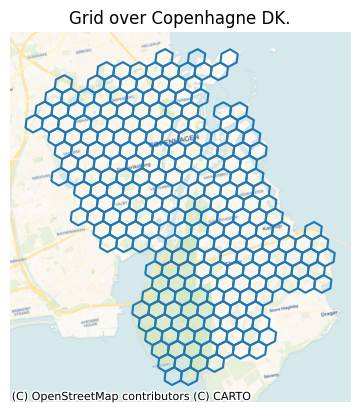

In [8]:
fig, ax = plt.subplots(1,1)
grid.boundary.plot(ax=ax)
cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Voyager, crs = grid.crs)
ax.set_axis_off()
ax.set_title("Grid over Copenhagne DK.")

#### Merge the datasets so the population data is on the hexagons

In [9]:
grid_with_pop, postal_hex_intersections = allocate_population_to_hexagons(
    grid=grid,
    postal_gdf=postal_gdf,
    population_df=pop_df,
    postal_code_col="postnummer",
    population_code_col="postal_code",
    population_col="population"
)

pointes_weighted = points.merge(
    grid_with_pop[["cell_id", "hex_population"]],
    on="cell_id",
    how="left"
)

pointes_weighted["hex_population"] = pointes_weighted["hex_population"].fillna(0)
pointes_weighted["weight"] = pointes_weighted["hex_population"]

### Visulise the data at this point

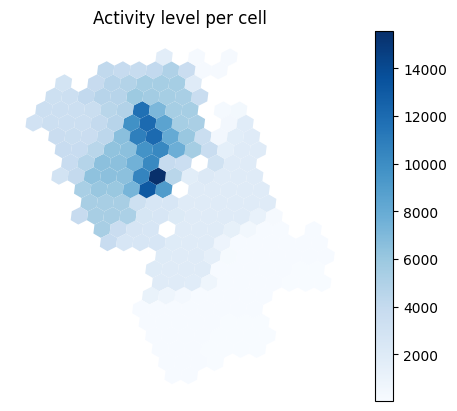

In [10]:
grid_heatmap = grid.merge(
    pointes_weighted[["cell_id", "weight"]],
    on="cell_id",
    how="left"
)

grid_heatmap["weight_int"] = grid_heatmap["weight"].astype(int)

fig, ax = plt.subplots(1,1)
grid_heatmap.plot(
    ax=ax,
    column="weight_int",
    cmap = "Blues",
    legend=True
)
ax.set_axis_off()
ax.set_title("Activity level per cell");

#### Create the OD dataset based on the map

In [11]:
## creating the pair list and weight for each node based on the trips taken from and to each node/station
# If data isnt created or new travel data needs to be generated, use the following line to create the OD matrix and save it as a CSV. 
# If you already have the CSV, you can skip this step and directly load it with pd.read_csv() as shown in the next line.
# od_df_tocsv = generate_trip_weight(points, 10, 380)
# od_df_tocsv.to_csv("../data/synthetic_od_data_matrix.csv", index=False)

od_df = pd.read_csv("../data/od_data_matrix.csv")

## Finding the surrounding/connecting hexagons to each hexagon
valid_connections = finding_neighbors(pointes_weighted, grid)

possible_neighbors = grid.merge(
    valid_connections[["cell_id", "vicinity"]],
    on="cell_id",
    how="left"
)

## Finding total system demand
total_demand = od_df["weight"].sum()

## Optimized version of calc_score, so time is decreased
pair_weights = defaultdict(float)
for row in od_df.itertuples():
    o, d, w = row.o, row.d, row.weight
    key = (min(o, d), max(o, d))
    pair_weights[key] += w

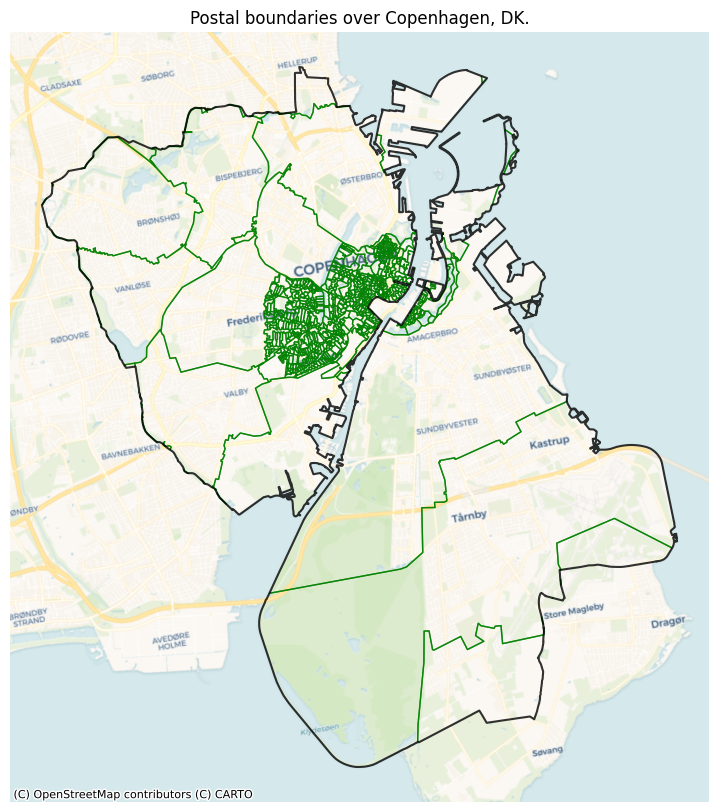

In [22]:
# make a graph of where the postal boundaries are being shown on the Copenhagen map

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Work on copies so the original objects are not changed
postal_plot = postal_gdf.copy()
study_area = my_polygon.copy()

# Ensure same CRS
if postal_plot.crs != study_area.crs:
    postal_plot = postal_plot.to_crs(study_area.crs)

if grid.crs != study_area.crs:
    grid = grid.to_crs(study_area.crs)

# Make sure postal code is text
postal_plot["postnummer"] = postal_plot["postnummer"].astype(str)

# Remove invalid/empty geometries
postal_plot = postal_plot[postal_plot.geometry.notna()].copy()
postal_plot = postal_plot[~postal_plot.geometry.is_empty].copy()

# Select ALL postal-code polygons that intersect your study area
# This includes København, Frederiksberg, Tårnby/Kastrup etc. if they touch my_polygon
study_union = study_area.union_all()

postal_in_area = postal_plot[
    postal_plot.intersects(study_union)
].copy()

if postal_in_area.empty:
    raise ValueError(
        "No postal-code polygons intersect my_polygon. Check CRS and my_polygon."
    )

# IMPORTANT:
# Convert polygons to boundary lines FIRST.
# Then clip the boundary lines.
# This avoids artificial red boundaries caused by clipping polygons.
postal_boundary_lines = postal_in_area.copy()
postal_boundary_lines["geometry"] = postal_boundary_lines.geometry.boundary

postal_boundary_lines = gpd.clip(
    postal_boundary_lines,
    study_area
)

postal_boundary_lines = postal_boundary_lines[
    postal_boundary_lines.geometry.notna()
].copy()
postal_boundary_lines = postal_boundary_lines[
    ~postal_boundary_lines.geometry.is_empty
].copy()

# Plot postal boundary lines
postal_boundary_lines.plot(
    ax=ax,
    linewidth=1,
    color="green",
    alpha=0.8
)

# Plot your Copenhagen/Frederiksberg/Tårnby study area outline
study_area.boundary.plot(
    ax=ax,
    linewidth=1.5,
    color="black",
    alpha=0.8
)

# Optional: plot grid on top
# grid.boundary.plot(ax=ax, linewidth=0.6, color="blue", alpha=0.5)

# Zoom to study area
xmin, ymin, xmax, ymax = study_area.total_bounds

xpad = (xmax - xmin) * 0.05
ypad = (ymax - ymin) * 0.05

ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

# Add basemap
cx.add_basemap(
    ax=ax,
    source=cx.providers.CartoDB.Voyager,
    crs=study_area.crs
)

ax.set_axis_off()
ax.set_title("Postal boundaries over Copenhagen, DK.")

plt.show()